# 05 — Deep Learning

## Objetivo

Evaluar cuánto valor predictivo adicional aportan redes neuronales densas frente
a los modelos estadísticos y de Machine Learning desarrollados previamente.

Se estudiarán tres componentes:

1. frecuencia de siniestros mediante una MLP con pérdida Poisson;
2. severidad mediante una MLP para respuestas positivas;
3. costo agregado mediante modelado directo y mediante Frecuencia × Severidad.

Se compararán dos estrategias de diseño:

- una arquitectura construida mediante una heurística de tipo embudo;
- una arquitectura seleccionada mediante optimización bayesiana.

La partición de test utilizada en los notebooks anteriores permanecerá
completamente intacta. Toda selección de arquitectura e hiperparámetros se
realizará exclusivamente dentro de la muestra de entrenamiento.

## 1 Configuración

### 1.1 Imports

In [1]:
import sys
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    mean_poisson_deviance,
    mean_gamma_deviance,
    mean_tweedie_deviance
)

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.metrics import (
    regression_metrics,
    relative_improvement
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponibles:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponibles: []


### 1.2 Carga de datos y split

In [3]:
DATA_PATH = Path(
    "../data/raw/synthetic_insurance_portfolio.csv"
)

SPLIT_PATH = Path(
    "../data/processed/train_test_split.csv"
)

df = pd.read_csv(DATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

df = df.merge(
    split_df,
    on="policy_id",
    how="left",
    validate="one_to_one"
)

assert df["split"].notna().all()

df_train = (
    df[df["split"] == "train"]
    .copy()
)

df_test = (
    df[df["split"] == "test"]
    .copy()
)

print(f"Train maestro: {len(df_train):,}")
print(f"Test maestro:  {len(df_test):,}")

Train maestro: 8,000
Test maestro:  2,000


### 1.3 Train/validation para Deep Learning

Una red neuronal utiliza validation repetidamente durante el entrenamiento, por lo que es importante separar la base de entrenamiento:

$$8000
\rightarrow
\begin{cases}
6400 & \text{DL train}\\
1600 & \text{DL validation}
\end{cases}$$

In [5]:
dl_train_idx, dl_val_idx = train_test_split(
    df_train.index,
    test_size=0.20,
    random_state=SEED,
    stratify=df_train["tuvo_siniestro"]         # Estratificamos por esta variable, para que validation no tenga
    )                                           # una proporción distinta de pólizas con siniestro


df_dl_train = (
    df_train.loc[dl_train_idx]
    .copy()
)

df_dl_val = (
    df_train.loc[dl_val_idx]
    .copy()
)

print(f"DL Train:      {len(df_dl_train):,}")
print(f"DL Validation: {len(df_dl_val):,}")
print(f"Test externo:  {len(df_test):,}")

DL Train:      6,400
DL Validation: 1,600
Test externo:  2,000


In [6]:
dl_split_df = pd.DataFrame({
    "policy_id": df_train["policy_id"],
    "dl_split": np.where(
        df_train.index.isin(dl_train_idx),
        "train",
        "validation"
    )
})

DL_SPLIT_PATH = Path(
    "../data/processed/dl_train_validation_split.csv"
)

dl_split_df.to_csv(
    DL_SPLIT_PATH,
    index=False
)

dl_split_df["dl_split"].value_counts()

dl_split
train         6400
validation    1600
Name: count, dtype: int64

### 1.4 Verificación del split


In [7]:
split_check = pd.DataFrame({
    "DL train": [
        df_dl_train["numero_siniestros"].mean(),
        df_dl_train["tuvo_siniestro"].mean(),
        df_dl_train["costo_siniestros"].mean()
    ],

    "DL validation": [
        df_dl_val["numero_siniestros"].mean(),
        df_dl_val["tuvo_siniestro"].mean(),
        df_dl_val["costo_siniestros"].mean()
    ],

    "Test": [
        df_test["numero_siniestros"].mean(),
        df_test["tuvo_siniestro"].mean(),
        df_test["costo_siniestros"].mean()
    ]
}, index=[
    "Frecuencia media",
    "Proporción con siniestro",
    "Costo medio"
])

split_check

,DL train,DL validation,Test
Frecuencia media,0.155156,0.153750,0.157500
Proporción con siniestro,0.141406,0.141250,0.146000
Costo medio,1960.630332,1842.367217,2008.681614


## 2. Preprocesamiento para redes neuronales

La red neuronal es sensible a las escalas distintas durante la optimización por gradiente, por eso las variables númericas se van a estandarizar.

$$x^*=\frac{x-\mu}{\sigma}.$$

In [8]:
NUMERIC_FEATURES = [
    "edad",
    "anios_vehiculo",
    "historial_siniestros"
]

A las variables categóricas las codificamos con One-Hot

In [9]:
CATEGORICAL_FEATURES = [
    "zona",
    "cobertura",
    "tipo_uso"
]

In [10]:
FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

In [11]:
preprocessor_dl = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)

Solo **ajustamos** de esta forma a la base de DL train y a la base de DL Validation y Test se lo **aplicamos**, para evitar **data leakage**

In [12]:
X_dl_train = preprocessor_dl.fit_transform(
    df_dl_train[FEATURES]
)

X_dl_val = preprocessor_dl.transform(
    df_dl_val[FEATURES]
)

X_dl_test = preprocessor_dl.transform(
    df_test[FEATURES]
)

In [13]:
X_dl_train = X_dl_train.astype(np.float32)
X_dl_val = X_dl_val.astype(np.float32)
X_dl_test = X_dl_test.astype(np.float32)

print("Train:", X_dl_train.shape)
print("Validation:", X_dl_val.shape)
print("Test:", X_dl_test.shape)

Train: (6400, 14)
Validation: (1600, 14)
Test: (2000, 14)


In [ ]:
n0 = X_dl_train.shape[1]        # Entradas de la capa de entrada (variables)
d = X_dl_train.shape[0]         # Batch completo

print("d =", d)
print("n0 =", n0)

d = 6400
n0 = 14


## 3. Frecuencia

**Targets**

In [15]:
y_freq_train = (
    df_dl_train["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

y_freq_val = (
    df_dl_val["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

y_freq_test = (
    df_test["numero_siniestros"]
    .to_numpy(dtype=np.float32)
)

lambda_true_test = (
    df_test["lambda_real"]
    .to_numpy(dtype=np.float32)
)

In [16]:
pd.DataFrame({
    "Train": pd.Series(y_freq_train).describe(),
    "Validation": pd.Series(y_freq_val).describe(),
    "Test": pd.Series(y_freq_test).describe()
})

,Train,Validation,Test
count,6400.000000,1600.000000,2000.000000
mean,0.155156,0.153750,0.157500
std,0.400603,0.395549,0.397206
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,4.000000,3.000000,3.000000


### 3.1 Arquitectura heurística

In [17]:
import math
from dataclasses import dataclass
from typing import List, Union

In [18]:
@dataclass
class DisenoRedRegresion:
    capas: List[int]
    P: int
    rho: float
    l2: float
    dropouts: List[float]
    patience: int
    min_delta: float
    max_epochs: int

In [21]:
def estimar_parametros(n0: int, capas: List[int]) -> int:
    """
    Cuenta parámetros de una red densa:
      - incluye sesgos en cada capa
      - incluye capa de salida (1 neurona)
    """
    if not capas:
        return 0

    P = (n0 + 1) * capas[0]
    for i in range(1, len(capas)):
        P += (capas[i - 1] + 1) * capas[i]
    P += (capas[-1] + 1) * 1
    return int(P)

In [22]:
def disenar_red_embudo_regresion(
    d: int,
    n0: int,
    *,
    k: int = 10,
    c1: float = 2.0,
    r: float = 0.5,
    n_min: int = 8,
    L_max: int = 4,
) -> Union[DisenoRedRegresion, str]:
    """
      - d  : número de muestras
      - n0 : número de variables de entrada (features)
    Devuelve:
      - DisenoRedRegresion si es viable
      - str con mensaje si no es viable
      
    1. Definición del Presupuesto de Parámetros (P_max)
    2. Diseño de la Arquitectura (Estructura en Embudo)
    3. Control y Recorte Dinámico
    4. Asignación de Regularización y Manejo del Riesgo
    """
    ####################################
    # 1. Definición del Presupuesto de Parámetros (P_max)
    ####################################

    # 0. Tope adaptativo de ancho (según tamaño de muestra)
    # Define un límite superior para la cantidad de neuronas en una sola capa según el tamaño del dataset (d).
    n_max = min(1024, max(64, math.floor(0.25 * d)))

    # 1. Verificación mínima de viabilidad (suave)
    if d < 2 * n0:
        return "Dataset muy pequeño: alto riesgo de sobreajuste"

    # 2. Presupuesto total de parámetros
    # Establece una regla de oro: la cantidad total de pesos y sesgos (P) no 
    # debería superar k x d (por defecto, 10 veces el número de muestras). Esto evita el sobreajuste (overfitting).
    P_max = math.floor(k * d)

    ####################################
    # 2. Diseño de la Arquitectura (Estructura en Embudo)
    ####################################

    # 3. Tamaño de la primera capa oculta (capado por presupuesto y por n_max)
    # Primera capa (n1): La inicializa proporcionalmente al número de características
    # de entrada (n0 x c1), pero recortada por el presupuesto y n_max
    n1_cap_presupuesto = math.floor(P_max / (n0 + 1))
    n1 = min(math.floor(c1 * n0), n1_cap_presupuesto, n_max) # c1 = 2.0 por defecto

    if n1 < n_min:
        return "Presupuesto insuficiente: no se puede ni una capa >= n_min"

    capas = [int(n1)]

    # Capas siguientes (Bucle while): Cada capa adicional reduce sus neuronas a la mitad (r = 0.5) de la capa anterior. 
    # Esto genera un diseño en forma de embudo (por ejemplo: 64 -> 32 -> 16). 
    # Se detiene si llega al máximo de capas (L_max = 4) o si el ancho cae por debajo de un mínimo seguro (n_min = 8).
    # 4. Construcción iterativa de capas ocultas (embudo)
    while True:
        if len(capas) >= L_max: # L_max = 4 por defecto
            break

        n_prev = capas[-1]
        n_new = math.floor(r * n_prev) # r = 0.5 por defecto

        if n_new < n_min: # n_min = 8 por defecto
            break

        n_new = min(n_new, n_max) # 
        capas.append(int(n_new))

    ####################################
    # 3. Control y Recorte Dinámico
    ####################################

    # 5. Estimación de parámetros (incluye sesgos y salida)
    P = estimar_parametros(n0, capas) # Cuenta el número total de parámetros de la red (pesos + sesgos + salida)

    # 6. Validación de complejidad (recorte iterativo)
    # Bucle de recorte (while P > P_max): Si la red generada excede el presupuesto de parámetros (P > P_{max}), 
    # el script primero intenta eliminar la última capa. Si solo queda una capa, 
    # va reduciendo suavemente su número de neuronas hasta que la red quepa dentro del presupuesto.
    while P > P_max:
        if len(capas) > 1:
            capas.pop()
        else:
            n_old = capas[0]
            capas[0] = math.floor(0.9 * capas[0])  # reducción suave
            if capas[0] >= n_old:
                capas[0] = n_old - 1               # garantiza progreso
            if capas[0] < n_min:
                return "Presupuesto insuficiente: no cabe una capa >= n_min"

        P = estimar_parametros(n0, capas)

    # ========================================================
    # 7. HIPERPARÁMETROS DE REGULARIZACIÓN (L2, Dropout, ES)
    # ========================================================

    ####################################
    # 3. Control y Recorte Dinámico
    ####################################

    # Una vez definida la estructura, el código evalúa rho (rho), 
    # que mide qué tan llena está la red respecto al presupuesto máximo (rho = P / P_{max}):

    # 7.1 Ocupación del presupuesto
    rho = P / P_max if P_max > 0 else 1.0

    # -------- Dropout base por tamaño de muestra --------
    # Dropout Adaptativo:Si el dataset es pequeño (d < 2000), 
    # se requiere mayor regularización (alto dropout base = 0.35).
    if d < 2000:
        drop_base = 0.35
    elif d < 20000:
        drop_base = 0.25
    else:
        drop_base = 0.15

    # -------- Ajuste por ocupación rho --------
    # Si la ocupación rho es alta (>= 0.8), aumenta el dropout un 10% extra.
    if rho >= 0.8:
        drop = drop_base + 0.10
    elif rho >= 0.4:
        drop = drop_base
    else:
        drop = drop_base - 0.10
    drop = clip(drop, 0.05, 0.50)

    # Dropout por capa (más alto al inicio)
    # Aplica un gradiente de dropout: las capas iniciales tienen más dropout 
    # que las capas profundas (drop * (1.0 - 0.15 * (i - 1))).
    dropouts: List[float] = []
    for i in range(1, len(capas) + 1):
        di = drop * (1.0 - 0.15 * (i - 1))
        di = clip(di, 0.05, 0.50)
        dropouts.append(float(di))

    # -------- L2 base por tamaño de muestra --------
    # Penalización L2: Ajusta la pérdida de pesos en función del tamaño del dataset y la ocupación rho.
    if d < 2000:
        l2_base = 1e-3
    elif d < 20000:
        l2_base = 3e-4
    else:
        l2_base = 1e-4

    # -------- Ajuste por ocupación rho --------
    if rho >= 0.8:
        l2 = 3.0 * l2_base
    elif rho >= 0.4:
        l2 = 1.0 * l2_base
    else:
        l2 = 0.3 * l2_base
    l2 = clip(l2, 1e-6, 3e-3)

    # -------- Early stopping (patience) --------
    # Early Stopping: Ajusta la paciencia (patience) y las épocas máximas (max_epochs). 
    # Si tienes pocos datos, le da más épocas y mayor paciencia para aprender con calma; 
    # si tienes muchos datos, reduce las épocas porque la red convergerá más rápido por lote.
    if d < 2000:
        patience = 20
        max_epochs = 400
    elif d < 20000:
        patience = 15
        max_epochs = 200
    else:
        patience = 10
        max_epochs = 100

    # (opcional) min_delta fijo simple
    min_delta = 1e-4

    return DisenoRedRegresion(
        capas=capas,
        P=int(P),
        rho=float(rho),
        l2=float(l2),
        dropouts=dropouts,
        patience=int(patience),
        min_delta=float(min_delta),
        max_epochs=int(max_epochs),
    )

In [19]:
def clip(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))

In [ ]:
def build_poisson_mlp(
    n0,
    capas,
    l2_value,
    dropouts,
    learning_rate=1e-3
):

    assert len(capas) == len(dropouts)

    model = keras.Sequential()

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    for units, dr in zip(
        capas,
        dropouts
    ):

        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=keras.regularizers.l2(
                    l2_value
                )
            )
        )

        model.add(
            keras.layers.Dropout(dr)
        )

    # λ > 0
    model.add(
        keras.layers.Dense(
            1,
            activation="softplus"           # Es una función de activación razonable para el problema de regresion Poisson
        )
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=keras.losses.Poisson(),        # Métrica de pérdida ideal para el problema

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

### 3.2 Generación de la arquitectura heurística

In [23]:
diseno_freq = disenar_red_embudo_regresion(
    d=d,
    n0=n0
)

diseno_freq

DisenoRedRegresion(capas=[28, 14], P=841, rho=0.013140625, l2=8.999999999999999e-05, dropouts=[0.15, 0.1275], patience=15, min_delta=0.0001, max_epochs=200)

In [26]:
capas_freq = diseno_freq.capas
l2_freq = diseno_freq.l2
dropouts_freq = diseno_freq.dropouts
patience_freq = diseno_freq.patience
min_delta_freq = diseno_freq.min_delta
max_epochs_freq = diseno_freq.max_epochs

print("Arquitectura:", capas_freq)
print("Parámetros estimados:", diseno_freq.P)
print("Ocupación presupuesto:", diseno_freq.rho)
print("L2:", l2_freq)
print("Dropout:", dropouts_freq)
print("Patience:", patience_freq)
print("Max epochs:", max_epochs_freq)

Arquitectura: [28, 14]
Parámetros estimados: 841
Ocupación presupuesto: 0.013140625
L2: 8.999999999999999e-05
Dropout: [0.15, 0.1275]
Patience: 15
Max epochs: 200


### 3.3 Entrenamiento del MLP Poisson heurístico

In [27]:
mlp_freq_heuristic = build_poisson_mlp(
    n0=n0,
    capas=capas_freq,
    l2_value=l2_freq,
    dropouts=dropouts_freq,
    learning_rate=1e-3
)

mlp_freq_heuristic.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks_freq = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience_freq,
        min_delta=min_delta_freq,
        restore_best_weights=True,
        verbose=1       
    )
]

In [31]:
start = time.perf_counter()

history_freq_heuristic = mlp_freq_heuristic.fit(
    X_dl_train,
    y_freq_train,

    validation_data=(
        X_dl_val,
        y_freq_val
    ),

    epochs=max_epochs_freq,
    batch_size=32,

    callbacks=callbacks_freq,

    verbose=0
)

freq_heuristic_train_time = (
    time.perf_counter() - start
)

print(
    f"Tiempo de entrenamiento: "
    f"{freq_heuristic_train_time:.2f} segundos"
)

print(
    f"Épocas ejecutadas: "
    f"{len(history_freq_heuristic.history['loss'])}"
)

Epoch 33: early stopping
Restoring model weights from the end of the best epoch: 18.
Tiempo de entrenamiento: 11.19 segundos
Épocas ejecutadas: 33


### 3.4 Curvas de aprendizaje

La pérdida Poisson de entrenamiento disminuye progresivamente durante el
entrenamiento, mientras que la pérdida de validación alcanza su mínimo alrededor
de la época 18 y posteriormente permanece estable con ligeras oscilaciones.

La divergencia posterior entre ambas curvas indica el inicio de un
sobreajuste moderado: la red continúa mejorando su ajuste sobre las
observaciones de entrenamiento sin conseguir una mejora equivalente fuera de
muestra.

El mecanismo de Early Stopping detiene el entrenamiento en la época 33 y
restaura automáticamente los pesos correspondientes a la época 18, evitando
conservar las actualizaciones posteriores que no mejoraron la pérdida de
validación.

In [32]:
history_freq_df = pd.DataFrame(
    history_freq_heuristic.history
)

history_freq_df.tail()

,loss,mae,val_loss,val_mae
28,0.418502,0.250260,0.430709,0.250907
29,0.416819,0.249014,0.430882,0.253284
30,0.420279,0.251014,0.430733,0.251096
31,0.418332,0.249760,0.430970,0.250954
32,0.418688,0.249252,0.430838,0.253002


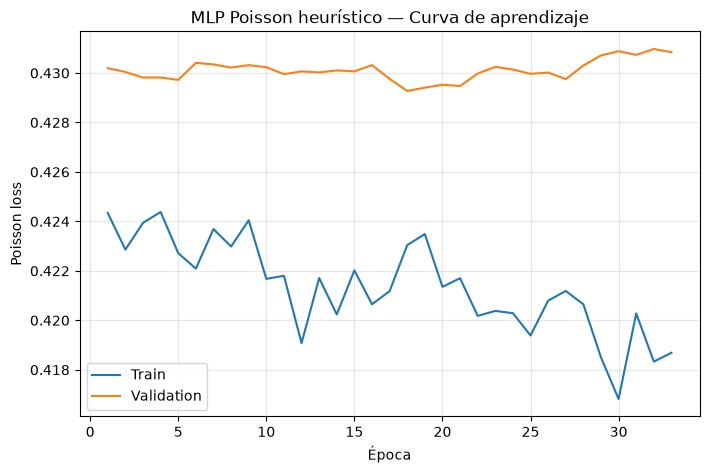

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["loss"],
    label="Train"
)

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["val_loss"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("Poisson loss")
plt.title(
    "MLP Poisson heurístico — Curva de aprendizaje"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

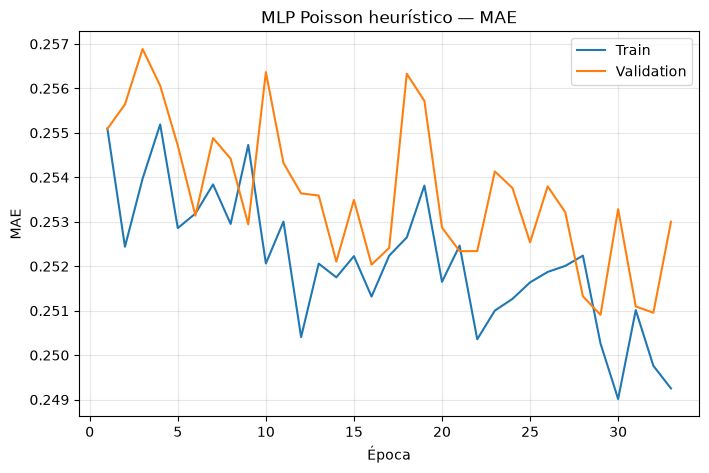

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["mae"],
    label="Train"
)

plt.plot(
    history_freq_df.index + 1,
    history_freq_df["val_mae"],
    label="Validation"
)

plt.xlabel("Época")
plt.ylabel("MAE")
plt.title(
    "MLP Poisson heurístico — MAE"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 3.5 ¿Cuál fue la mejor época?

In [36]:
best_epoch_freq = (
    np.argmin(
        history_freq_heuristic.history["val_loss"]
    )
    + 1
)

best_val_loss_freq = np.min(
    history_freq_heuristic.history["val_loss"]
)

print(
    f"Mejor época: {best_epoch_freq}"
)

print(
    f"Mejor val_loss: "
    f"{best_val_loss_freq:.6f}"
)

Mejor época: 18
Mejor val_loss: 0.429275


### 3.6 Predicciones

In [37]:
pred_train_freq_mlp_heur = (
    mlp_freq_heuristic
    .predict(
        X_dl_train,
        verbose=0
    )
    .ravel()
)

pred_val_freq_mlp_heur = (
    mlp_freq_heuristic
    .predict(
        X_dl_val,
        verbose=0
    )
    .ravel()
)

pred_test_freq_mlp_heur = (
    mlp_freq_heuristic
    .predict(
        X_dl_test,
        verbose=0
    )
    .ravel()
)

La frecuencia predicha media es de 0.1579 vs una frecuencia observada de 0.1575 esto se traduce en una diferencia relativa de 0.29% aproximadamente, por lo que la caibración agregada es buena.

In [46]:
# Veamos si softplus hizo que todas las predicciones son mayores que 0
print(
    "Predicción mínima test:",
    pred_test_freq_mlp_heur.min()
)

print(
    "Predicción máxima test:",
    pred_test_freq_mlp_heur.max()
)

print(
    "Predicción media test:",
    pred_test_freq_mlp_heur.mean()
)

print(
    "Frecuencia observada test:",
    y_freq_test.mean()
)

print(
    "Diferencia Relativa",
    (pred_test_freq_mlp_heur.mean()-y_freq_test.mean())/y_freq_test.mean()

)

Predicción mínima test: 0.042301543
Predicción máxima test: 0.82399446
Predicción media test: 0.15795514
Frecuencia observada test: 0.1575
Diferencia Relativa 0.0028897845


### 3.7 Train, validation y test

Los resultados muestran un deterioro progresivo:

$$\text{train} < \text{validation} < \text{test},$$

Pero la diferencia no es grande, por lo que el comportamiento es bastante bueno, no hay ratro de sobreajuste.

De acuerdo a los resultados: la red neuronal generaliza razonablemente, pero su función aprendida no es precisa.

In [39]:
freq_train_metrics_heur = regression_metrics(
    y_freq_train,
    pred_train_freq_mlp_heur
)

freq_val_metrics_heur = regression_metrics(
    y_freq_val,
    pred_val_freq_mlp_heur
)

freq_test_metrics_heur = regression_metrics(
    y_freq_test,
    pred_test_freq_mlp_heur
)

pd.DataFrame(
    [
        freq_train_metrics_heur,
        freq_val_metrics_heur,
        freq_test_metrics_heur
    ],
    index=[
        "Train",
        "Validation",
        "Test"
    ]
)

,MAE,RMSE
Train,0.252469,0.384521
Validation,0.256329,0.391243
Test,0.260463,0.393500


In [40]:
freq_train_deviance_heur = (
    mean_poisson_deviance(
        y_freq_train,
        pred_train_freq_mlp_heur
    )
)

freq_val_deviance_heur = (
    mean_poisson_deviance(
        y_freq_val,
        pred_val_freq_mlp_heur
    )
)

freq_test_deviance_heur = (
    mean_poisson_deviance(
        y_freq_test,
        pred_test_freq_mlp_heur
    )
)

pd.DataFrame({
    "Poisson_deviance": [
        freq_train_deviance_heur,
        freq_val_deviance_heur,
        freq_test_deviance_heur
    ]
}, index=[
    "Train",
    "Validation",
    "Test"
])

,Poisson_deviance
Train,0.553996
Validation,0.581459
Test,0.598432


### 3.8 Oracle

La MLP con la arquitectura heurística obtiene buenos resultados, pero aún son inferiores a los que se encontraron con los modelos finales de GLM, Random Forest y XGBoost.

La MLP sigue bien el patrón relativo del riesgo, incluso mejor que el RF, pero falla más en magnitud.

In [41]:
freq_oracle_metrics_heur = regression_metrics(
    lambda_true_test,
    pred_test_freq_mlp_heur
)

freq_oracle_corr_heur = np.corrcoef(
    lambda_true_test,
    pred_test_freq_mlp_heur
)[0, 1]

print(
    f"Oracle MAE: "
    f"{freq_oracle_metrics_heur['MAE']:.6f}"
)

print(
    f"Oracle RMSE: "
    f"{freq_oracle_metrics_heur['RMSE']:.6f}"
)

print(
    f"Oracle correlation: "
    f"{freq_oracle_corr_heur:.4f}"
)

Oracle MAE: 0.028397
Oracle RMSE: 0.041276
Oracle correlation: 0.8883


### 3.9 Bayesian Optimization

La arquitectura heurística proporciona un punto de partida razonable para la
red neuronal, pero sus decisiones no se basan directamente en el desempeño
observado del modelo.

Por ejemplo, la heurística determinó:

- 2 capas ocultas;
- arquitectura 28 → 14;
- dropout de 0.15 y 0.1275;
- regularización L2 de 9e-5;
- learning rate fijo de 1e-3.

Estas decisiones están sustentadas por reglas predefinidas relacionadas con
el tamaño del dataset y el número de variables, pero no sabemos si constituyen
la mejor configuración para el problema actual.

Por ello se utilizará optimización bayesiana para explorar diferentes
combinaciones de hiperparámetros utilizando exclusivamente el conjunto de
validación.

El conjunto de test permanecerá completamente aislado durante todo el proceso
de selección.

#### Hiperparámetros

Los parámetros de una red neuronal pueden dividirse en dos grupos.

**Parámetros aprendidos durante el entrenamiento**

Son los pesos y sesgos de la red:

$$
W,\;b
$$

y son actualizados automáticamente mediante backpropagation y descenso por
gradiente.

**Hiperparámetros**

Son decisiones externas al entrenamiento, por ejemplo:

- número de capas;
- número de neuronas;
- learning rate;
- dropout;
- penalización L2;
- batch size.

Estos valores no son aprendidos directamente mediante backpropagation y deben
ser seleccionados mediante algún procedimiento adicional.


#### Objetivo de la búsqueda

Cada conjunto de hiperparámetros define una arquitectura diferente.

Sea:

$$
h = (L,n_1,r,d,\lambda,\eta)
$$

el conjunto de hiperparámetros de una red.

El objetivo de la optimización es encontrar:

$$
h^* =
\arg\min_h L_{\mathrm{validation}}(h)
$$

donde $L_{\mathrm{validation}}$ corresponde a la pérdida Poisson calculada
sobre el conjunto de validación.

El conjunto de test no participa en esta optimización.

#### ¿Por qué optimización bayesiana?

Una búsqueda aleatoria selecciona cada combinación de hiperparámetros
independientemente de los resultados anteriores.

La optimización bayesiana utiliza los experimentos ya realizados para construir
un modelo probabilístico aproximado de la relación:

$$
h \longrightarrow L_{\mathrm{validation}}.
$$

Después utiliza este modelo para seleccionar qué combinación evaluar a
continuación.

La búsqueda intenta equilibrar dos comportamientos:

- **Exploitation:** probar regiones que parecen prometedoras.
- **Exploration:** investigar regiones sobre las cuales existe mayor
  incertidumbre.

Por ello puede encontrar buenas configuraciones utilizando menos evaluaciones
que una exploración exhaustiva del espacio.

In [56]:
import keras_tuner as kt
import tensorboard

print("TensorFlow:", tf.__version__)
print("Keras Tuner:", kt.__version__)
print("TensorBoard:", tensorboard.__version__)

TensorFlow: 2.21.0
Keras Tuner: 1.4.8
TensorBoard: 2.21.0


#### 3.9.1 Definición del espacio de búsqueda

In [57]:
SEARCH_SPACE = {
    "n_layers": "1 a 4",
    "first_units": [16, 32, 64, 128],
    "reduction": [0.5, 0.75, 1.0],
    "dropout": "0.00 a 0.40",
    "l2": "1e-6 a 1e-2",
    "learning_rate": "1e-4 a 3e-3"
}

SEARCH_SPACE

{'n_layers': '1 a 4',
 'first_units': [16, 32, 64, 128],
 'reduction': [0.5, 0.75, 1.0],
 'dropout': '0.00 a 0.40',
 'l2': '1e-6 a 1e-2',
 'learning_rate': '1e-4 a 3e-3'}

#### 3.9.2 Constructor de modelos para Bayesian Optimization

**Escala logarítmica**

Algunos hiperparámetros no deben explorarse de forma uniforme en escala lineal.

Por ejemplo, para L2 pueden ser razonables valores como:

$$
10^{-6},10^{-5},10^{-4},10^{-3},10^{-2}.
$$

La diferencia relevante está en los órdenes de magnitud.

Por este motivo `sampling="log"` permite explorar de manera más apropiada
hiperparámetros como:

- regularización L2;
- learning rate.

In [58]:
def build_poisson_mlp_tuned(hp):
    """
    Construye una MLP para frecuencia Poisson cuyos hiperparámetros
    son seleccionados por Keras Tuner.

    La red estima:

        lambda_hat(X) = E[N | X]

    por lo que utiliza una salida Softplus para garantizar
    predicciones estrictamente positivas.
    """

    # ---------------------------------------------------------
    # 1. Número de capas ocultas
    # ---------------------------------------------------------
    n_layers = hp.Int(
        name="n_layers",
        min_value=1,
        max_value=4,
        step=1
    )

    # ---------------------------------------------------------
    # 2. Número de neuronas de la primera capa
    # ---------------------------------------------------------
    first_units = hp.Choice(
        name="first_units",
        values=[16, 32, 64, 128]
    )

    # ---------------------------------------------------------
    # 3. Factor de reducción entre capas
    #
    # 0.50 → embudo fuerte
    # 0.75 → embudo moderado
    # 1.00 → ancho constante
    # ---------------------------------------------------------
    reduction = hp.Choice(
        name="reduction",
        values=[0.5, 0.75, 1.0]
    )

    # ---------------------------------------------------------
    # 4. Dropout
    # ---------------------------------------------------------
    dropout = hp.Float(
        name="dropout",
        min_value=0.0,
        max_value=0.40,
        step=0.05
    )

    # ---------------------------------------------------------
    # 5. Penalización L2
    #
    # sampling="log" es importante porque queremos explorar
    # órdenes de magnitud:
    #
    # 1e-6, ..., 1e-4, ..., 1e-2
    # ---------------------------------------------------------
    l2_value = hp.Float(
        name="l2",
        min_value=1e-6,
        max_value=1e-2,
        sampling="log"
    )

    # ---------------------------------------------------------
    # 6. Learning rate
    #
    # También se busca en escala logarítmica.
    # ---------------------------------------------------------
    learning_rate = hp.Float(
        name="learning_rate",
        min_value=1e-4,
        max_value=3e-3,
        sampling="log"
    )

    # =========================================================
    # CONSTRUCCIÓN DE LA RED
    # =========================================================

    model = keras.Sequential(
        name="poisson_mlp_bayesian"
    )

    model.add(
        keras.layers.Input(
            shape=(n0,)
        )
    )

    units = first_units

    for layer_idx in range(n_layers):

        # Evitamos capas excesivamente pequeñas.
        units_current = max(
            8,
            int(round(units))
        )

        model.add(
            keras.layers.Dense(
                units=units_current,
                activation="relu",

                kernel_regularizer=(
                    keras.regularizers.l2(
                        l2_value
                    )
                )
            )
        )

        if dropout > 0:

            model.add(
                keras.layers.Dropout(
                    rate=dropout
                )
            )

        # Ancho de la siguiente capa
        units *= reduction

    # ---------------------------------------------------------
    # Salida positiva
    #
    # λ_hat > 0
    # ---------------------------------------------------------
    model.add(
        keras.layers.Dense(
            units=1,
            activation="softplus"
        )
    )

    # =========================================================
    # COMPILACIÓN
    # =========================================================

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=keras.losses.Poisson(),

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

#### 3.9.2 Crear el Bayesian Optimizer

In [59]:
import shutil

In [ ]:
TUNER_DIR = Path(
    "../results/tuning/frequency_bayesian"
)

# Elimina resultados.
if TUNER_DIR.exists():
    shutil.rmtree(TUNER_DIR)

In [61]:
tuner_freq = kt.BayesianOptimization(
    hypermodel=build_poisson_mlp_tuned,

    # Métrica que Bayes intentará minimizar.
    objective=kt.Objective(
        "val_loss",
        direction="min"
    ),

    # Número máximo de arquitecturas evaluadas.
    max_trials=20,

    # Una ejecución por configuración.
    executions_per_trial=1,

    seed=SEED,

    directory=str(TUNER_DIR),

    project_name="poisson_mlp",

    overwrite=True
)

#### 3.9.3 Inspeccionar espacio antes de entrenar

In [64]:
tuner_freq.search_space_summary()

Search space summary
Default search space size: 6
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
first_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
reduction (Choice)
{'default': 0.5, 'conditions': [], 'values': [0.5, 0.75, 1.0], 'ordered': True}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.05, 'sampling': 'linear'}
l2 (Float)
{'default': 1e-06, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.003, 'step': None, 'sampling': 'log'}


#### 3.9.4 Early Stopping durante la búsqueda

In [65]:
tuning_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=0
)

#### 3.9.5 Ejecutar la búsqueda

**Independencia del conjunto de test**

Durante la optimización bayesiana únicamente se utilizarán:

- `X_dl_train`, `y_freq_train` para actualizar los pesos;
- `X_dl_val`, `y_freq_val` para seleccionar hiperparámetros.

Las 2,000 observaciones del conjunto de test no se utilizarán para:

- seleccionar arquitectura;
- seleccionar learning rate;
- seleccionar regularización;
- aplicar early stopping.

Esto evita adaptar indirectamente el modelo al conjunto de evaluación final.

In [66]:
start = time.perf_counter()

tuner_freq.search(
    X_dl_train,
    y_freq_train,

    validation_data=(
        X_dl_val,
        y_freq_val
    ),

    epochs=120,

    batch_size=32,

    callbacks=[
        tuning_early_stopping
    ],

    verbose=1
)

freq_bayesian_search_time = (
    time.perf_counter()
    - start
)

print(
    "\nTiempo total de Bayesian Optimization: "
    f"{freq_bayesian_search_time:.2f} segundos"
)

Trial 20 Complete [00h 00m 16s]
val_loss: 0.42744410037994385

Best val_loss So Far: 0.42563462257385254
Total elapsed time: 00h 07m 41s

Tiempo total de Bayesian Optimization: 460.85 segundos


### 3.9.6 Revisar los mejores trials

In [67]:
tuner_freq.results_summary(
    num_trials=10
)

Results summary
Results in ..\results\tuning\frequency_bayesian\poisson_mlp
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
n_layers: 2
first_units: 16
reduction: 0.75
dropout: 0.15000000000000002
l2: 3.8254014699751585e-06
learning_rate: 0.00072182541156161
Score: 0.42563462257385254

Trial 18 summary
Hyperparameters:
n_layers: 2
first_units: 16
reduction: 0.75
dropout: 0.15000000000000002
l2: 3.998760281764063e-06
learning_rate: 0.00027207465661591574
Score: 0.42672330141067505

Trial 19 summary
Hyperparameters:
n_layers: 3
first_units: 16
reduction: 1.0
dropout: 0.2
l2: 1.4204469313224143e-06
learning_rate: 0.0005087182645972488
Score: 0.42744410037994385

Trial 07 summary
Hyperparameters:
n_layers: 3
first_units: 16
reduction: 1.0
dropout: 0.05
l2: 3.8900529061079076e-05
learning_rate: 0.00013175913780684667
Score: 0.42871466279029846

Trial 06 summary
Hyperparameters:
n_layers: 4
first_units: 16
reduction: 0.5
dropout: 0.2
l2: 

In [68]:
best_hp_freq = (
    tuner_freq
    .get_best_hyperparameters(
        num_trials=1
    )[0]
)

In [69]:
print(
    "Mejores hiperparámetros "
    "encontrados:\n"
)

for name, value in (
    best_hp_freq.values.items()
):

    print(
        f"{name:<20}: {value}"
    )

Mejores hiperparámetros encontrados:

n_layers            : 2
first_units         : 16
reduction           : 0.75
dropout             : 0.15000000000000002
l2                  : 3.8254014699751585e-06
learning_rate       : 0.00072182541156161


### 3.9.7 Reconstruir la arquitectura ganadora

In [70]:
best_n_layers = (
    best_hp_freq.get("n_layers")
)

best_first_units = (
    best_hp_freq.get("first_units")
)

best_reduction = (
    best_hp_freq.get("reduction")
)

best_architecture = []

units = best_first_units

for _ in range(best_n_layers):

    current_units = max(
        8,
        int(round(units))
    )

    best_architecture.append(
        current_units
    )

    units *= best_reduction

print(
    "Arquitectura encontrada:",
    " → ".join(
        map(str, best_architecture)
    )
)

Arquitectura encontrada: 16 → 12
